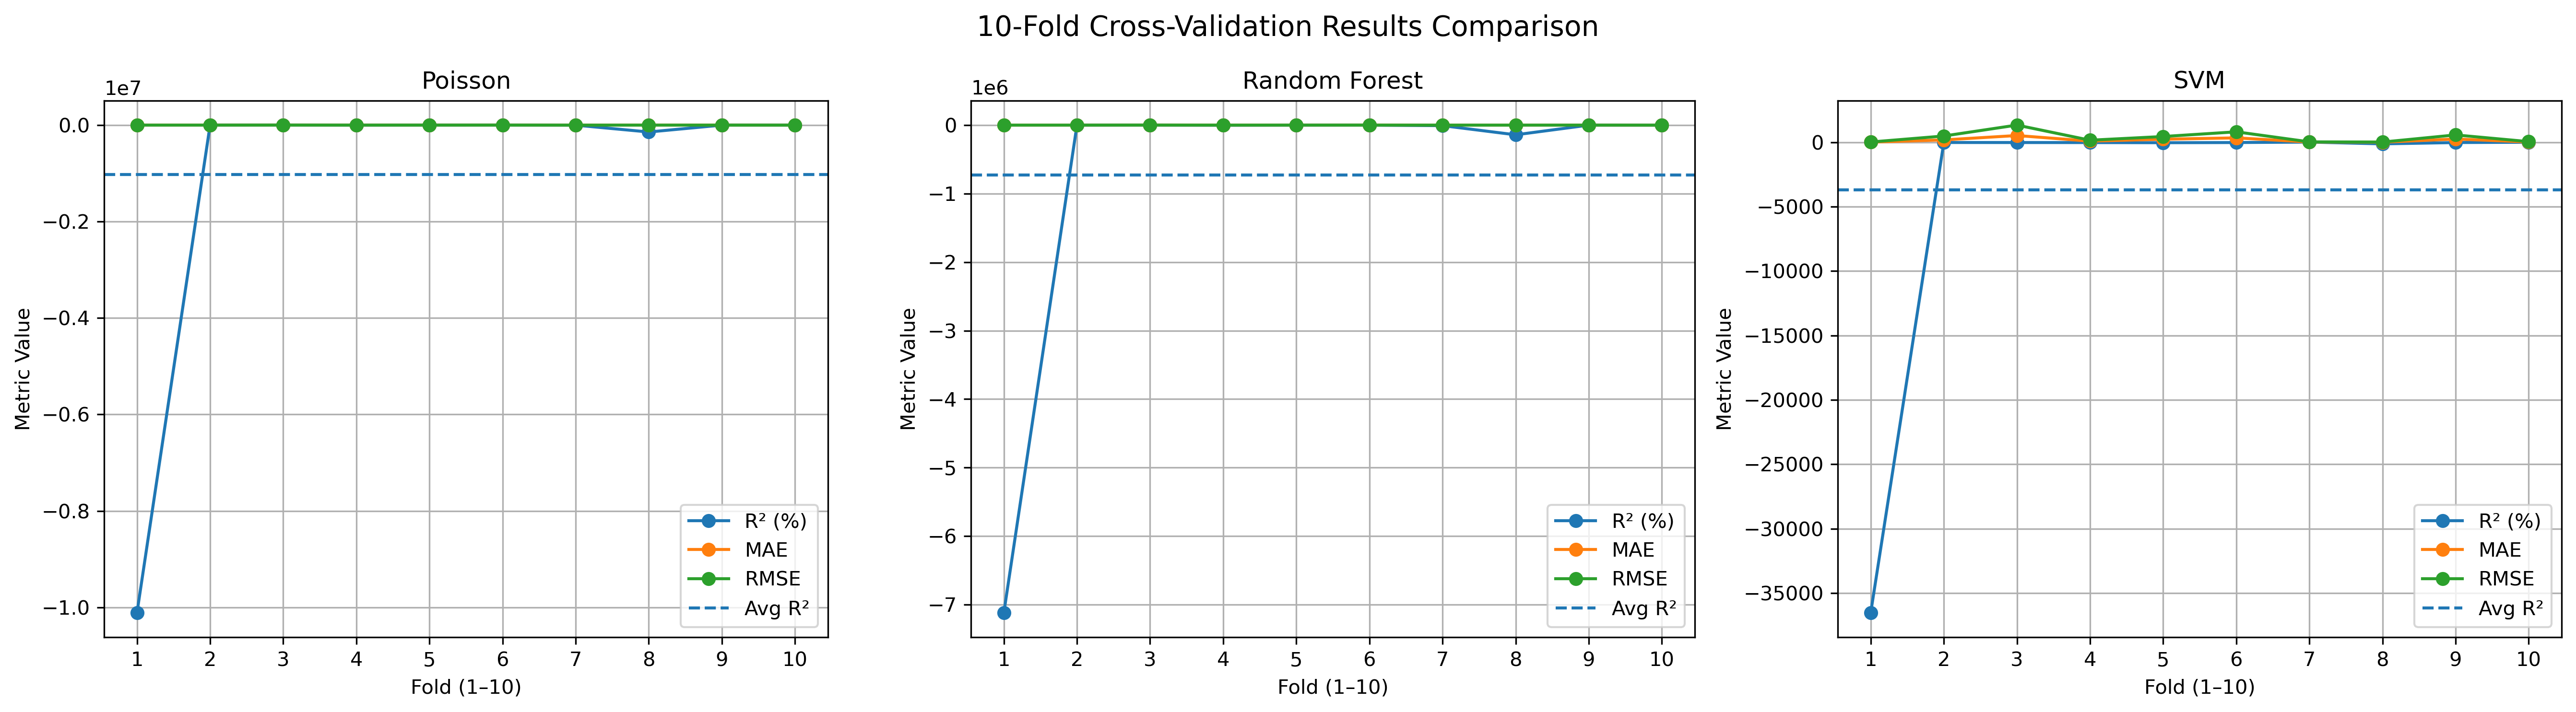


===== FINAL MODEL COMPARISON =====

Poisson:
  Avg R²  = -1025794.81
  Avg MAE = 231.75
  Avg RMSE= 444.70

Random Forest:
  Avg R²  = -727190.77
  Avg MAE = 282.62
  Avg RMSE= 501.41

SVM:
  Avg R²  = -3675.45
  Avg MAE = 171.77
  Avg RMSE= 395.09



In [3]:
# ==========================================
# FULL WORKFLOW (CORRECTED)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# LOAD DATA
df = pd.read_csv(r"C:\Users\dhrub\Desktop\Data\kaski_env_dengue_merged.csv")

# SORT
df = df.sort_values(["year","month"]).reset_index(drop=True)

# CREATE LAGS
df["NDVI_lag"] = df["NDVI"].shift(0)
df["LST_lag"] = df["LST_Day"].shift(4)
df["Precip_lag"] = df["Precip"].shift(2)

df = df.dropna()

# VARIABLES
X = df[["NDVI_lag","LST_lag","Precip_lag"]]
y = df["dengue_cases"]

# ==========================================
# CROSS VALIDATION SETUP
# ==========================================

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# ✅ FIX 1: Use 10 folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Store results
results = {
    "Poisson": {"r2": [], "mae": [], "rmse": []},
    "Random Forest": {"r2": [], "mae": [], "rmse": []},
    "SVM": {"r2": [], "mae": [], "rmse": []}
}

# ✅ FIX 2: Correct fold numbers
folds = list(range(1, 11))

# ==========================================
# CROSS VALIDATION LOOP
# ==========================================

for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # --------------------------
    # 1. POISSON MODEL
    # --------------------------
    X_train_sm = sm.add_constant(X_train)
    X_test_sm = sm.add_constant(X_test)

    poisson = sm.GLM(y_train, X_train_sm, family=sm.families.Poisson()).fit()
    y_pred_pois = poisson.predict(X_test_sm)

    # --------------------------
    # 2. RANDOM FOREST
    # --------------------------
    rf = RandomForestRegressor(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # --------------------------
    # 3. SVM (✅ FIXED WITH SCALING)
    # --------------------------
    svm = make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=10, gamma="scale")
    )
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)

    # --------------------------
    # METRICS FUNCTION
    # --------------------------
    def compute_metrics(y_true, y_pred):
        r2 = r2_score(y_true, y_pred) * 100
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        return r2, mae, rmse

    # Store metrics
    for name, pred in zip(
        ["Poisson", "Random Forest", "SVM"],
        [y_pred_pois, y_pred_rf, y_pred_svm]
    ):
        r2, mae, rmse = compute_metrics(y_test, pred)

        results[name]["r2"].append(r2)
        results[name]["mae"].append(mae)
        results[name]["rmse"].append(rmse)

# ==========================================
# PLOTTING (CLEAN + STABLE)
# ==========================================

plt.figure(figsize=(18,5), dpi=300)

models = ["Poisson", "Random Forest", "SVM"]

for i, model in enumerate(models):

    plt.subplot(1,3,i+1)

    plt.plot(folds, results[model]["r2"], marker='o', label="R² (%)")
    plt.plot(folds, results[model]["mae"], marker='o', label="MAE")
    plt.plot(folds, results[model]["rmse"], marker='o', label="RMSE")

    # ✅ Optional: average line (very useful for report)
    plt.axhline(np.mean(results[model]["r2"]), linestyle='--', label="Avg R²")

    plt.title(model)
    plt.xlabel("Fold (1–10)")
    plt.ylabel("Metric Value")
    plt.xticks(folds)
    plt.legend()
    plt.grid(True)

plt.suptitle("10-Fold Cross-Validation Results Comparison", fontsize=14)

plt.tight_layout()
plt.show()

# ==========================================
# PRINT FINAL AVERAGE RESULTS
# ==========================================

print("\n===== FINAL MODEL COMPARISON =====\n")

for model in models:
    print(f"{model}:")
    print(f"  Avg R²  = {np.mean(results[model]['r2']):.2f}")
    print(f"  Avg MAE = {np.mean(results[model]['mae']):.2f}")
    print(f"  Avg RMSE= {np.mean(results[model]['rmse']):.2f}")
    print()